In [ ]:
#required libraries
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras

In [ ]:
#Importing the dataset
data=pd.read_csv("/content/Bank Customer Churn Prediction.csv")
print(data.head())

   customer_id  credit_score country  gender  age  tenure    balance  \
0     15634602           619  France  Female   42       2       0.00   
1     15647311           608   Spain  Female   41       1   83807.86   
2     15619304           502  France  Female   42       8  159660.80   
3     15701354           699  France  Female   39       1       0.00   
4     15737888           850   Spain  Female   43       2  125510.82   

   products_number  credit_card  active_member  estimated_salary  churn  
0                1            1              1         101348.88      1  
1                1            0              1         112542.58      0  
2                3            1              0         113931.57      1  
3                2            0              0          93826.63      0  
4                1            1              1          79084.10      0  


In [ ]:
#Define featues and outcome
x=data.drop(['customer_id','churn'],axis=1,errors='ignore')
y=data['churn']
print(x.head())

   credit_score country  gender  age  tenure    balance  products_number  \
0           619  France  Female   42       2       0.00                1   
1           608   Spain  Female   41       1   83807.86                1   
2           502  France  Female   42       8  159660.80                3   
3           699  France  Female   39       1       0.00                2   
4           850   Spain  Female   43       2  125510.82                1   

   credit_card  active_member  estimated_salary  
0            1              1         101348.88  
1            0              1         112542.58  
2            1              0         113931.57  
3            0              0          93826.63  
4            1              1          79084.10  


In [ ]:
x = pd.get_dummies(x, drop_first=True)
print(x.head())

   credit_score  age  tenure    balance  products_number  credit_card  \
0           619   42       2       0.00                1            1   
1           608   41       1   83807.86                1            0   
2           502   42       8  159660.80                3            1   
3           699   39       1       0.00                2            0   
4           850   43       2  125510.82                1            1   

   active_member  estimated_salary  country_Germany  country_Spain  \
0              1         101348.88            False          False   
1              1         112542.58            False           True   
2              0         113931.57            False          False   
3              0          93826.63            False          False   
4              1          79084.10            False           True   

   gender_Male  
0        False  
1        False  
2        False  
3        False  
4        False  


In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
le = LabelEncoder()

# Label encode categorical features
x['gender']=le.fit_transform(x['gender'])
x['country']=le.fit_transform(x['country'])

# Identify numerical features to scale
numerical_cols = ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary']

# Initialize and apply StandardScaler
scaler = StandardScaler()
x[numerical_cols] = scaler.fit_transform(x[numerical_cols])

print(x.head())

   credit_score  country  gender       age    tenure   balance  \
0     -0.326221        0       0  0.293517 -1.041760 -1.225848   
1     -0.440036        2       0  0.198164 -1.387538  0.117350   
2     -1.536794        0       0  0.293517  1.032908  1.333053   
3      0.501521        0       0  0.007457 -1.387538 -1.225848   
4      2.063884        2       0  0.388871 -1.041760  0.785728   

   products_number  credit_card  active_member  estimated_salary  
0        -0.911583            1              1          0.021886  
1        -0.911583            0              1          0.216534  
2         2.527057            1              0          0.240687  
3         0.807737            0              0         -0.108918  
4        -0.911583            1              1         -0.365276  


In [ ]:
from sklearn.model_selection import train_test_split

#split data for train and test and validation
x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.3, random_state=42)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42)

In [ ]:
# Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)
x_test = scaler.transform(x_test)

In [ ]:
#Build ANN Architecture
Model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(x_train.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [ ]:
Model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,881 (11.25 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Compiling the model
Model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
#Train the model
history = Model.fit(x_train, y_train,
   validation_data=(x_val, y_val),
   epochs=20, batch_size=32, verbose=0)

In [ ]:
# Evaluate
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, accuracy_score
import seaborn as sns

y_pred_probs = Model.predict(x_test).ravel()
y_pred = (y_pred_probs > 0.5).astype(int)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"AUC Score: {roc_auc_score(y_test, y_pred_probs):.4f}")

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Accuracy: 0.8627
AUC Score: 0.8597


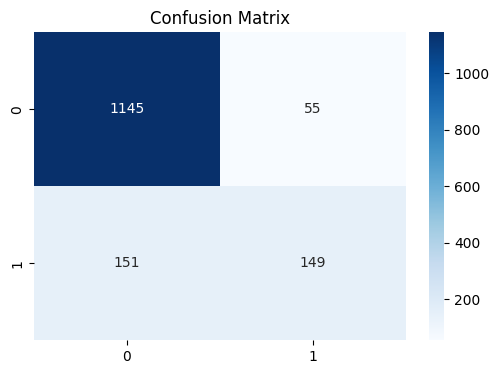

In [ ]:
import matplotlib.pyplot as plt

# Confusion Matrix Plot
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

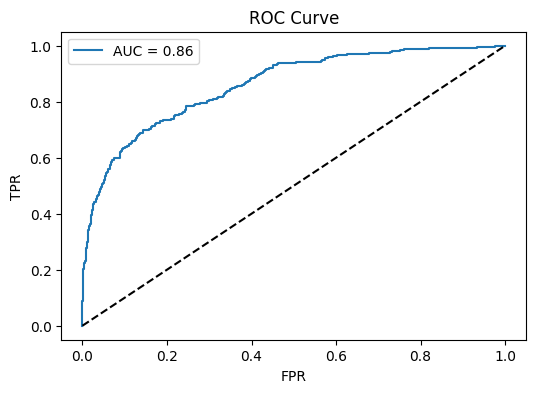

In [ ]:
# ROC Curve Plot
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_pred_probs):.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.legend(); plt.show()

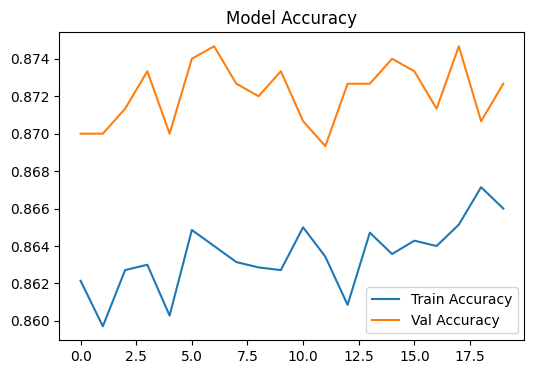

In [ ]:
# Training History Plot
plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.legend(); plt.show()